# Univariate fitting

Thin wrapper around `paper.experiments.univariate`.


In [1]:
from pathlib import Path

import matplotlib as mpl
import pandas as pd

from paper.experiments.univariate import PROFILES, run_profile
from paper.plotting import plot_scaling, plot_target_gallery
from paper.targets import TargetSpec
from paper.tuning import summarize_raw

mpl.rcParams['figure.dpi'] = 140


In [2]:
profile_name = 'full'
profile = PROFILES[profile_name]
raw_path = Path("runs") / f"univariate_{profile_name}.csv"
summary_path = Path("runs") / f"univariate_{profile_name}_summary.csv"


In [3]:
if raw_path.exists():
    raw = pd.read_csv(raw_path)
else:
    raw = run_profile(profile)
    raw_path.parent.mkdir(parents=True, exist_ok=True)
    raw.to_csv(raw_path, index=False)

expected_models = {"unconstrained", "monotone"}
if not expected_models <= set(raw["model"].unique()):
    raise ValueError(f"{raw_path} does not contain {sorted(expected_models)}; rerun this profile")

summary = summarize_raw(raw, profile.budgets)
summary.to_csv(summary_path, index=False)
summary.head()


,target_kind,complexity,noise_std,model,dim,eig_idx,budget,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,mean_test_rmse,n
0,monotone,5,0.0,monotone,5,2,1,0.1,0.822918,0.616683,0.919902,0.792168,16
1,monotone,5,0.0,monotone,5,2,2,0.1,0.619093,0.511563,0.774889,0.635777,16
2,monotone,5,0.0,monotone,5,2,5,0.1,0.379804,0.281665,0.500971,0.397235,16
3,monotone,5,0.0,monotone,5,2,10,0.1,0.242776,0.190915,0.299749,0.265148,16
4,monotone,5,0.0,monotone,5,2,20,0.1,0.239525,0.187521,0.280160,0.236435,16


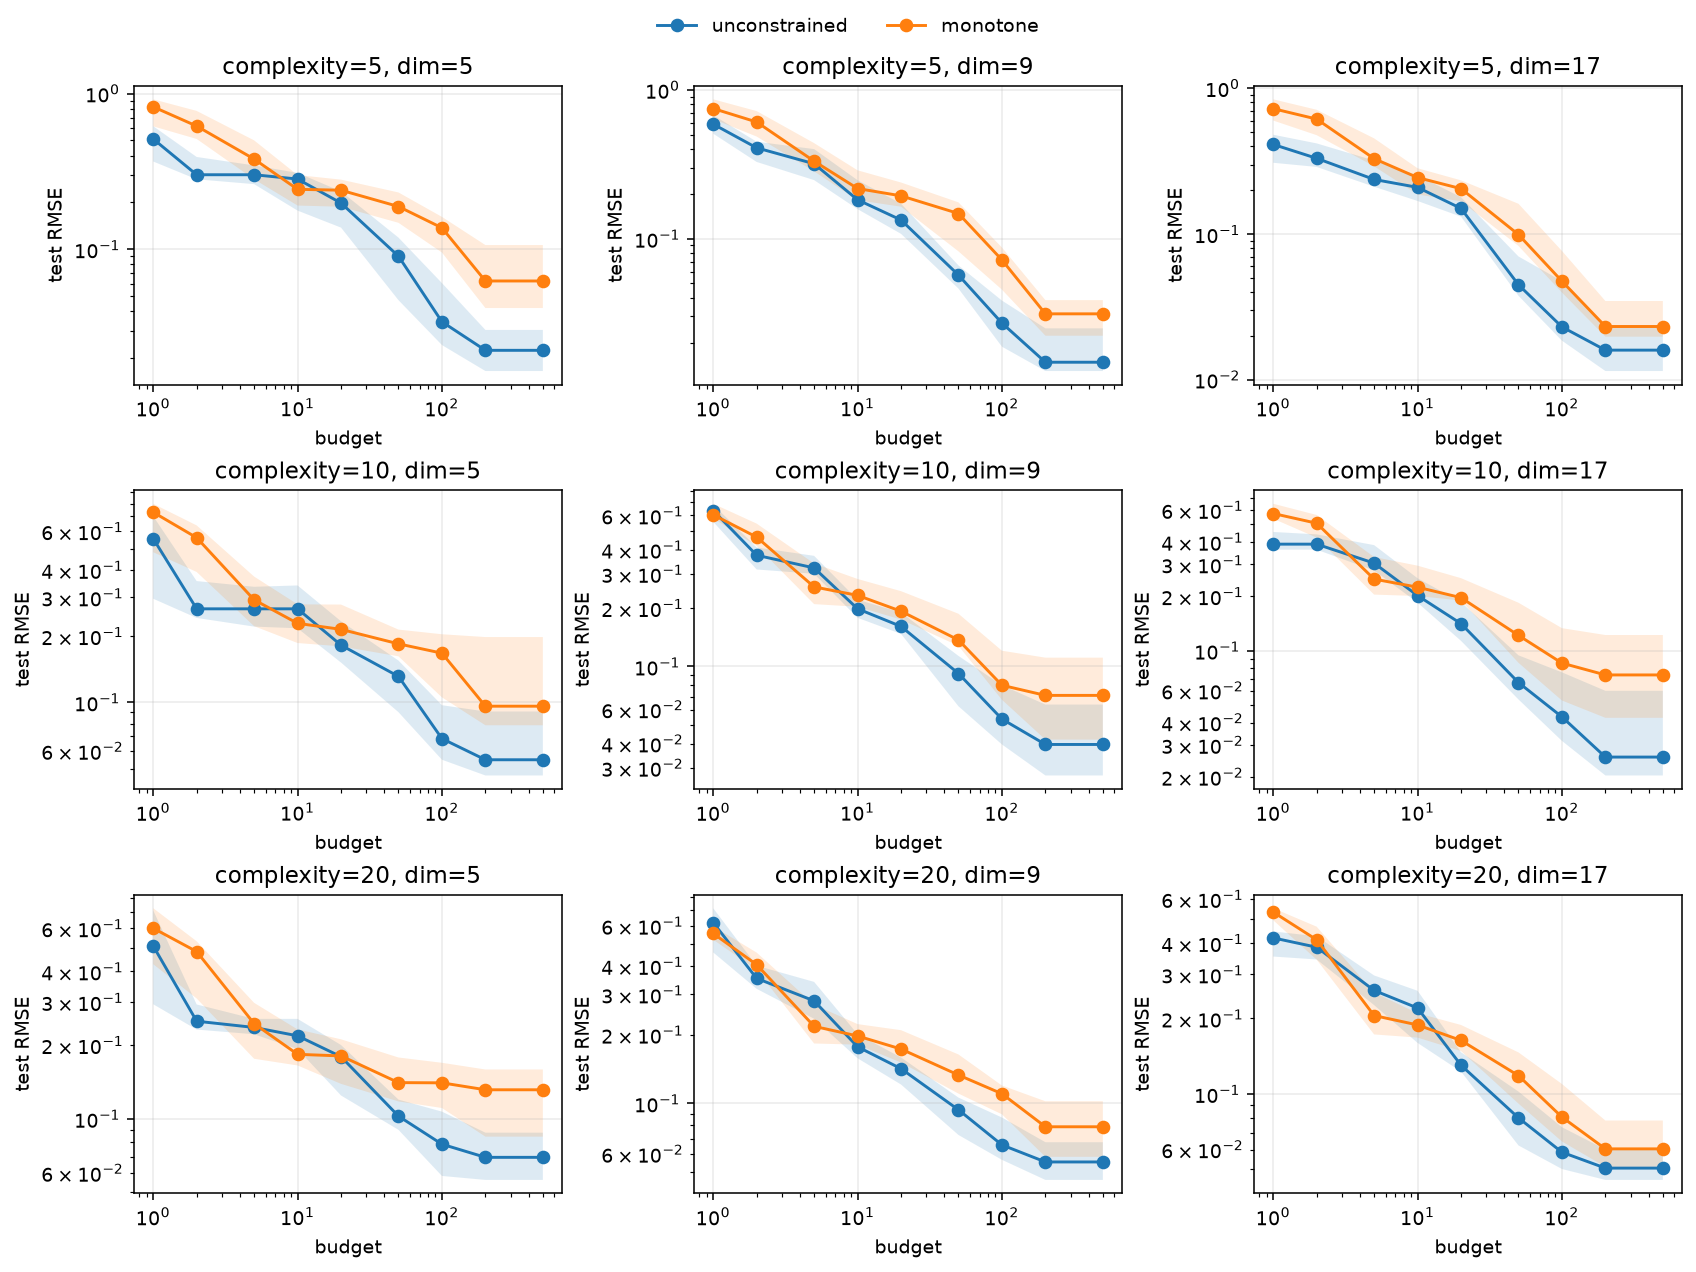

In [4]:
plot_scaling(summary);

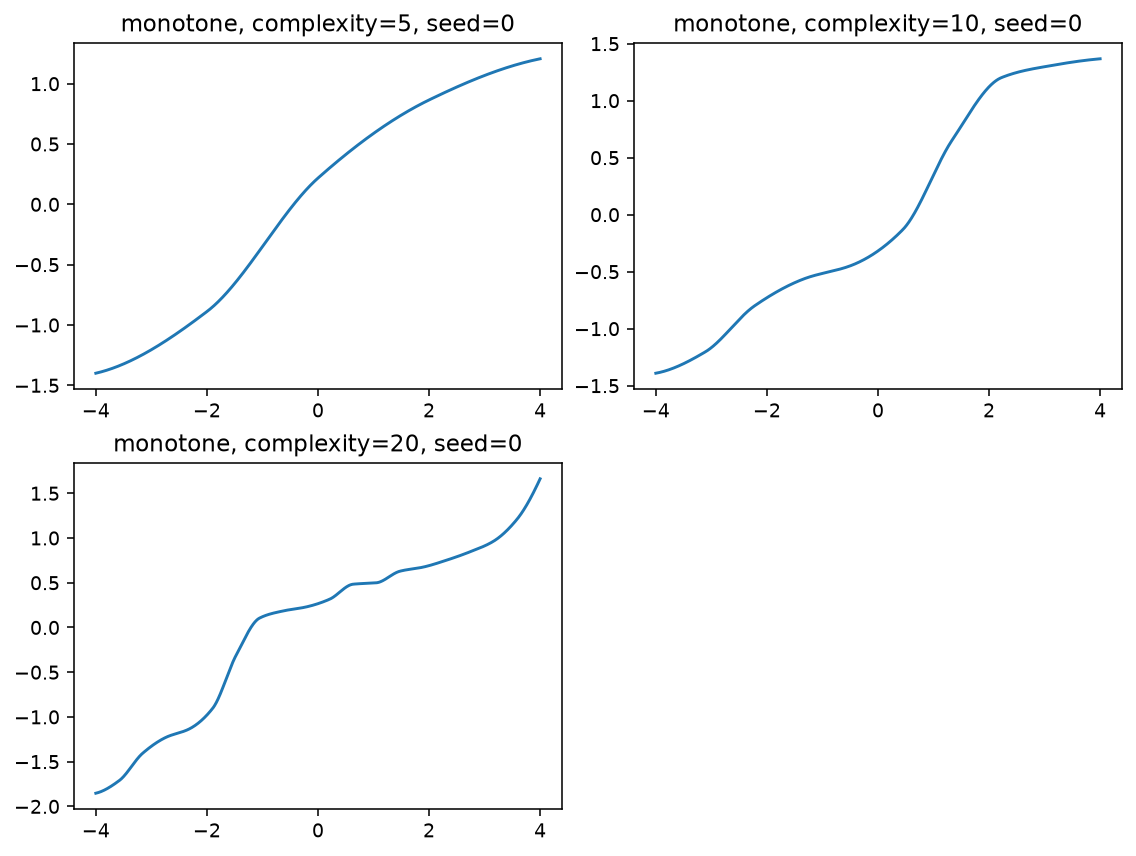

In [5]:
plot_target_gallery([
    TargetSpec(kind="monotone", complexity=complexity, seed=0)
    for complexity in profile.complexities
]);